In [15]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import jax.numpy as jnp
from jax import jit
import jax
from ksd import compute_ksd_jax
from jax import vmap, grad
import matplotlib.pyplot as plt
import numpy as np
from ot.sliced import sliced_wasserstein_distance as swd
from tqdm.auto import tqdm

from triangular_transport.mcmc.adaptive_mcmc import AdaptiveMCMC
from triangular_transport.kernels.kernel_tools import get_gaussianRBF, get_sum_of_kernels, vectorize_kfunc

plt.style.use("ggplot")

In [2]:
a = 2
b = 0.1
sigma_x = 1
cond_no = -1.0
nsamples = 100000

@jit
def density_V(u):
    y = cond_no
    scale = 1 / (2 * sigma_x**2)
    sum_part = (a * (y + b * (u**2 + a**2))) ** 2 + (u**2) / (a**2)
    return jnp.squeeze(jnp.exp(-scale * sum_part))

def alpha(x, w, log_density):
    log_w = log_density(w)
    log_x = log_density(x)
    return jnp.minimum(0.0, log_w - log_x)

In [3]:
adapt_mcmc = AdaptiveMCMC(
    target_density=density_V,
    alpha_function=alpha,
    seed=42,
    train_dim=1,
    steps=nsamples,
    name="Adaptive - Conditional",
    std_err=0.6,
    iter_step_adapt=1,
    cond_no=cond_no,
    burn_in=1, # TODO: Rerun everything with low burn_in
)

In [4]:
adapt_mcmc.fit(print_every=20000)

 20%|██        | 20125/100001 [00:28<01:48, 738.93it/s]

The acceptance rate is: 0.73565


 40%|████      | 40090/100001 [00:55<01:23, 717.00it/s]

The acceptance rate is: 0.739825


 60%|██████    | 60091/100001 [01:22<00:54, 735.85it/s]

The acceptance rate is: 0.74195


 80%|████████  | 80131/100001 [01:49<00:26, 752.88it/s]

The acceptance rate is: 0.7419375


100%|██████████| 100001/100001 [02:15<00:00, 736.27it/s]

The acceptance rate is: 0.74204


In [6]:
true_samps = np.load("rej_samples_1.npy")[np.random.choice(100000, (nsamples)), :]
mcmc_samps = np.array(adapt_mcmc.samples)
prior_samps = np.random.randn(nsamples, 1)

In [7]:
np.save("mcmc_samps.npy", mcmc_samps)

In [28]:
sample_no_list = [2**i for i in range(1, 15)]
sample_no_list.append(20000)
sample_no_list.append(30000)
sample_no_list.append(40000)
sample_no_list.append(50000)
sample_no_list.append(60000)
sample_no_list.append(70000)
sample_no_list.append(80000)
sample_no_list.append(90000)
sample_no_list.append(100000)

In [ ]:
n_projections = 2048
seed = 42

swd_array = np.zeros(len(sample_no_list))

for i, sample_no in enumerate(tqdm(sample_no_list)):
    swd1 = swd(
        mcmc_samps[:sample_no, :],
        true_samps[np.random.choice(nsamples, (sample_no,)), :], #TODO: Change this to include 20000 true samples
        n_projections=n_projections,
        seed=seed
    )

    swd_array[i] = swd1

100%|██████████| 23/23 [07:05<00:00, 18.50s/it]


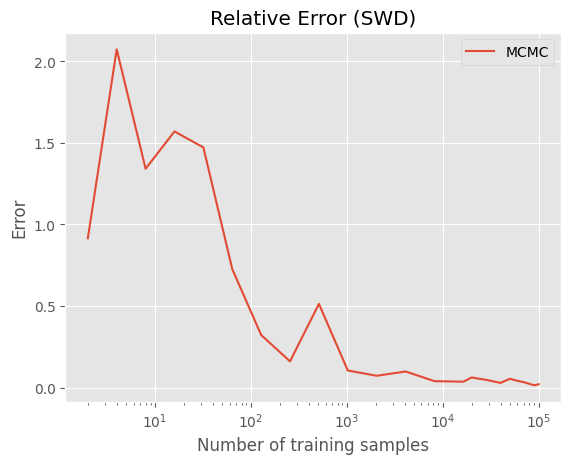

In [12]:
plt.plot(sample_no_list, swd_array, label="MCMC")
plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Number of training samples")
plt.ylabel("Error")
plt.title("Relative Error (SWD)")
plt.legend()

In [11]:
np.save("swd_array_mcmc.npy", swd_array)

In [17]:
def median_heuristic_sigma_jax(X, Y=None, max_points=5000, seed=0):
    X = jnp.asarray(X).reshape(X.shape[0], -1)
    if Y is not None:
        Y = jnp.asarray(Y).reshape(Y.shape[0], -1)
        Z = jnp.concatenate([X, Y], axis=0)
    else:
        Z = X

    n = Z.shape[0]
    if n > max_points:
        idx = jax.random.choice(
            jax.random.PRNGKey(seed), n, (max_points,), replace=False
        )
        Z = Z[idx]

    a2 = jnp.sum(Z * Z, axis=1, keepdims=True)
    D2 = a2 + a2.T - 2.0 * (Z @ Z.T)
    D2 = jnp.triu(D2, k=1)  # zero elsewhere
    D = jnp.sqrt(jnp.clip(D2[D2 > 0], a_min=0.0))
    sigma = jnp.median(D)
    return float(sigma)

In [19]:
gamma = median_heuristic_sigma_jax(prior_samps, true_samps)
k1 = get_gaussianRBF(gamma)
k2 = get_gaussianRBF(gamma - 6.0)
k3 = get_gaussianRBF(gamma - 3.0)
k4 = get_gaussianRBF(gamma + 3.0)
k5 = get_gaussianRBF(gamma + 6.0)
c1 = [0.2] * 5
kernels = [k1, k2, k3, k4, k5]
ker = get_sum_of_kernels(kernels, c1)

ker = vectorize_kfunc(ker)

ker_jit = jax.jit(ker)


@jax.jit
def MMD(X, Y):
    x_mean_emb = jnp.mean(ker(X, X))
    y_mean_emb = jnp.mean(ker(Y, Y))
    xy_mean_emb = jnp.mean(ker(X, Y))
    return x_mean_emb + y_mean_emb - 2 * xy_mean_emb


@jax.jit
def get_kme(X, Y):
    return (MMD(X, Y)) ** 2 / (jnp.mean(ker(Y, Y))) ** 2

In [21]:
mmd_array = np.zeros(len(sample_no_list))
for i, sample_no in enumerate(tqdm(sample_no_list)):
    mmd_array[i] = get_kme(mcmc_samps[: sample_no, :], true_samps[np.random.choice(nsamples, (sample_no, )), :])

100%|██████████| 23/23 [00:03<00:00,  6.32it/s]


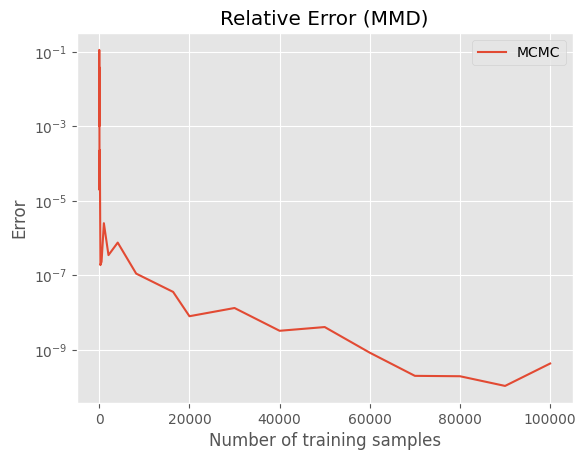

In [24]:
plt.plot(sample_no_list, mmd_array, label="MCMC")
# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of training samples")
plt.ylabel("Error")
plt.title("Relative Error (MMD)")
plt.legend()

In [25]:
np.save("mmd_array_mcmc.npy", mmd_array)

In [22]:
def log_density_V(u):
    y = cond_no
    scale = 1 / (2 * sigma_x**2)
    sum_part = (a * (y + b * (u**2 + a**2))) ** 2 + (u**2) / (a**2)
    return jnp.squeeze(-scale * sum_part)

score_V = vmap(vmap(grad(log_density_V)))
bandwidth = median_heuristic_sigma_jax(true_samps)
base_ksd = compute_ksd_jax(true_samps[np.random.choice(nsamples, (20000, )), :], score_V, bandwidth=bandwidth)

In [29]:
ksd_array = np.zeros(len(sample_no_list))
for i, sample_no in enumerate(tqdm(sample_no_list)):
    if sample_no <= 20000:
        ksd_array[i] = compute_ksd_jax(mcmc_samps[:sample_no, :], score_V, bandwidth=bandwidth)
    else:
        mcmc_sub = mcmc_samps[:sample_no, :]
        mcmc_sub = mcmc_sub[np.random.choice(mcmc_sub.shape[0], (20000, )), :]
        ksd_array[i] = compute_ksd_jax(mcmc_sub, score_V, bandwidth=bandwidth)

100%|██████████| 23/23 [00:01<00:00, 15.28it/s]


In [31]:
ksd_array / base_ksd

Array([-2.8198671 , -2.2044659 , -2.3798606 , -2.1959488 ,  9.841016  ,
        3.110183  ,  1.6913724 ,  1.1832423 ,  1.2902455 ,  1.2417438 ,
        1.0299808 ,  0.94718236,  1.0476439 ,  1.0729984 ,  1.1073561 ,
        1.1156837 ,  1.0570886 ,  1.0881224 ,  1.0413276 ,  1.0795451 ,
        1.0520566 ,  1.0484836 ,  1.0290289 ], dtype=float32)

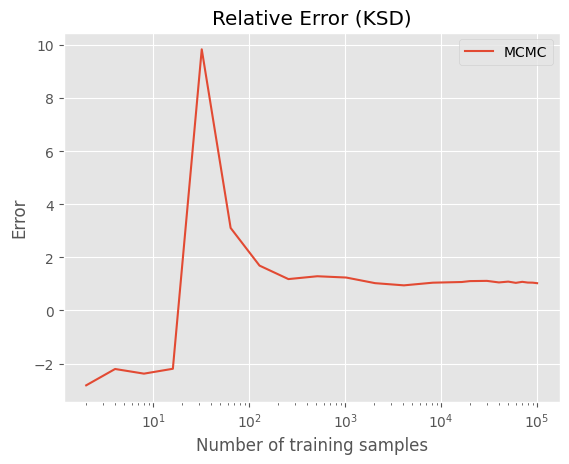

In [33]:
plt.plot(sample_no_list, ksd_array / base_ksd, label="MCMC")
plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Number of training samples")
plt.ylabel("Error")
plt.title("Relative Error (KSD)")
plt.legend()

In [34]:
np.save("ksd_array_mcmc.npy", ksd_array)